# Kernels: the two mean maps and the shared scale

`specdiff/kernels.py` is the entire model interface. Everything the sampler knows about your
diffusion model is three objects:

| you supply | base class | paper | called |
| --- | --- | --- | --- |
| $m^q_n$ | `TargetTransition` | eq. (5) | once per round, batched over the tree's internal nodes |
| $m^p_n$ | `ProposalTransition` | eq. (7) | once per tree *level* while drafting |
| $\{\sigma_n\}$ | `NoiseSchedule` | eq. (5), (37) | per step, by the sampler |

This notebook derives those three from the paper's problem setting, writes each one in code, and
checks the identities they are supposed to satisfy. Sections 1–2 are the derivation, 3–6 are the
three components, 7 is the role of the churn parameter, and 9 indexes every equation in the paper
against the place it lives in the library.

**Notation.** $d$ is the state dimension, $N$ the number of denoising steps, $\gamma = 1/N$ the
step size, $t_n = n\gamma$ the time grid, $\varepsilon \in [0, 1]$ the churn parameter,
and $\xi, \, \xi_n \sim \mathcal{N}(0, \mathbb{I}_d)$ standard Gaussian noise.

In [1]:
import numpy as np

from specdiff import (
    ConstantSchedule,
    DelayedDriftProposal,
    IdentityProposal,
    MirrorProposal,
    NoiseSchedule,
    ProposalTransition,
    TabulatedSchedule,
    TargetTransition,
)
from specdiff.ops import standard_normal_sf

import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

Matplotlib is building the font cache; this may take a moment.


## 1. From the SDE to two means and a scale

### 1.1 The forward and reverse processes

A DDPM defines a forward diffusion that gradually perturbs data with Gaussian noise. With
$X_0 \sim p_{\text{data}}$, the forward process $(X_t)_{t \in [0,1]}$ solves

$$\mathrm{d}X_t = f_t(X_t)\,\mathrm{d}t + g_t\,\mathrm{d}B_t \tag{1}$$

for a $d$-dimensional Brownian motion $(B_t)$. Generation simulates the associated *reverse-time*
process $(Y_t)_{t \in [0,1]}$,

$$\mathrm{d}Y_t = b^q_t(Y_t)\,\mathrm{d}t + \varepsilon\, g_{1-t}\,\mathrm{d}W_t \tag{2}$$

whose drift is built from the Stein score $s_t(x) = \nabla_x \log p_t(x)$:

$$b^q_t(x) = -f_{1-t}(x) + \frac{1 + \varepsilon^2}{2}\, g^2_{1-t}\, s_{1-t}(x) \tag{3}$$

$\varepsilon$ is the **churn parameter**. $\varepsilon = 1$ recovers the standard reverse-time SDE;
$\varepsilon = 0$ gives the deterministic probability-flow ODE. Section 7 shows why
$\varepsilon = 0$ is fatal for speculation.

### 1.2 Discretisation: where the two means come from

Simulating (2) needs a time grid. The paper uses the uniform one,

$$t_n = n\gamma, \qquad n = 0, \dots, N, \qquad \gamma = \frac{1}{N},$$

writes $Y_n := Y_{t_n}$, and applies the Euler–Maruyama step with
$\xi_n \sim \mathcal{N}(0, \mathbb{I}_d)$:

$$Y_{n+1} = Y_n + \gamma\, b^q_{t_n}(Y_n) + \sqrt{\gamma}\,\varepsilon\, g_{1-t_n}\, \xi_n \tag{4}$$

Conditional on $Y_n = y_n$ this is a Gaussian draw,
$Y_{n+1} \mid Y_n = y_n \sim \mathcal{N}\!\big(m^q_n(y_n),\, \sigma_n^2 \mathbb{I}_d\big)$, with

$$m^q_n(y) = y + \gamma\, b^q_{t_n}(y)
\qquad\text{and}\qquad
\sigma_n = \sqrt{\gamma}\,\varepsilon\, g_{1-t_n} \tag{5}$$

**Equation (5) is the whole interface.** `TargetTransition.means` returns $m^q_n(y)$ and
`NoiseSchedule.sigma` returns $\sigma_n$. The library never sees $f_t$, $g_t$, $s_t$ or $b^q_t$ —
only the mean map and the scale they combine into.

The discretised reverse process is then a Markov chain with joint density

$$q(y_0, \dots, y_N) = q_0(y_0) \prod_{n=0}^{N-1} q_n(y_{n+1} \mid y_n) \tag{6}$$

and $q_0$ is the initial Gaussian of the reverse process — which is why `sample()` takes `init`
from *you*: the initial law is a property of the model, not of the sampler.

| paper | code |
| --- | --- |
| $b^q_{t_n}$, the expensive network evaluation | inside your `means()` |
| $m^q_n(y) = y + \gamma b^q_{t_n}(y)$, eq. (5) | `TargetTransition.means(states, steps)` |
| $\sigma_n = \sqrt{\gamma}\varepsilon g_{1-t_n}$, eq. (5) | `NoiseSchedule.sigma(step)` |
| $q_0$ | the `init` argument of `sample()` |
| one NFE | one `TargetTransition.__call__` |

### 1.3 The proposal: eq. (7)

The bottleneck is $b^q_{t_n}$, evaluated afresh at every state. Speculative sampling replaces it,
for drafting only, with a cheaper mean map $m^p_n$. The paper adopts the **delayed reverse
drift**: reuse a drift already evaluated at an *earlier* state $y_k$,

$$m^p_n(y) = y + \gamma\, b^q_{t_k}(y_k), \qquad k < n \tag{7}$$

while keeping the same transition variance $\sigma_n^2 = \gamma \varepsilon^2 g^2_{1-t_n}$. No
second network, no extra training — the draft kernel differs from the target kernel *only* in
where the drift was evaluated.

That "same variance, different mean" structure is not incidental; it is the assumption the whole
method rests on.

## 2. The one modelling assumption: eq. (24)

Appendix C states the template the library implements. Fix a round starting at step $n$. The only
requirement on the two transitions is that they are **isotropic Gaussians sharing a variance and
differing in their means**:

$$\mathbb{P}_n(\cdot \mid y) = \mathcal{N}\!\big(m^p_n(y), \sigma_n^2 \mathbb{I}_d\big),
\qquad
\mathbb{Q}_n(\cdot \mid y) = \mathcal{N}\!\big(m^q_n(y), \sigma_n^2 \mathbb{I}_d\big) \tag{24}$$

with $m^q_n$ as in (5) and $m^p_n$ **arbitrary** — eq. (7) is one choice, a distilled draft network
is another, and the sampler cannot tell.

### Why the shared $\sigma_n$ is load-bearing

Because the two kernels differ only in mean, the $d$-dimensional coupling problem collapses to a
one-dimensional one. Writing $\mu_p = m^p_n(y)$ and $\mu_q = m^q_n(y)$, define

$$\Delta := \frac{\mu_q - \mu_p}{\sigma}, \qquad \delta := \lVert\Delta\rVert, \qquad e := \Delta/\delta \tag{8}$$

Standardising $Y$ as $Z := (Y - \mu_p)/\sigma$ gives $Z \sim \mathcal{N}(0, \mathbb{I}_d)$ under
$\mathbb{P}$ and $Z \sim \mathcal{N}(\delta e, \mathbb{I}_d)$ under $\mathbb{Q}$, and any
realisation decomposes orthogonally as

$$z = \underbrace{e\,e^\top z}_{s} + \underbrace{(\mathbb{I}_d - e\,e^\top) z}_{z_\perp} \tag{9}$$

Under either law the scalar $S = e^\top Z$ and the residual $Z_\perp$ are independent, and
$Z_\perp \sim \mathcal{N}(0, \mathbb{I}_d - e e^\top)$ under *both*. Only the scalar differs:
$S \sim \mathcal{N}(0,1)$ under $\mathbb{P}$ and $S \sim \mathcal{N}(\delta, 1)$ under
$\mathbb{Q}$. So a proposal is projected with

$$\widehat{S} := e^\top(\widehat{Y} - \mu_p)/\sigma, \qquad
Z_\perp := (\mathbb{I}_d - e e^\top)(\widehat{Y} - \mu_p)/\sigma \tag{10}$$

and a valid target scalar is lifted back with

$$Y = \mu_p + \sigma\,(S e + Z_\perp) \tag{11}$$

Everything about verification happens in that one scalar coordinate. Equations (8)–(11) live in
`specdiff/verifiers/rank1.py` and are the subject of the verifier tutorial; what matters *here* is
that **the kernels you write are what make them legal**, and that they determine the single number
$\delta$ that governs every acceptance probability in the paper — eq. (16) for RMC and eq. (15) for
D-GRS.

$$\delta = \frac{\lVert m^q_n(y) - m^p_n(y)\rVert}{\sigma_n}$$

A good proposal is exactly one that keeps $\delta$ small **relative to the noise it competes
with**. Both halves of that fraction are yours to choose.

## 3. `NoiseSchedule` — the shared scale $\sigma_n$

Subclasses implement `sigma(step)`. The sampler calls the *instance*, `schedule(n)`, and
`__call__` refuses a non-positive scale. That guard is Remark 3 of the paper made executable:

> **Remark 3 (The role of churn).** The churn level cannot be taken to zero. At $\varepsilon = 0$
> the scale (37) vanishes, both transitions degenerate to point masses, and their total variation
> distance equals one, so every proposal is rejected and speculation reduces to the standard
> sampler.

A general-purpose schedule, plus the two shipped ones:

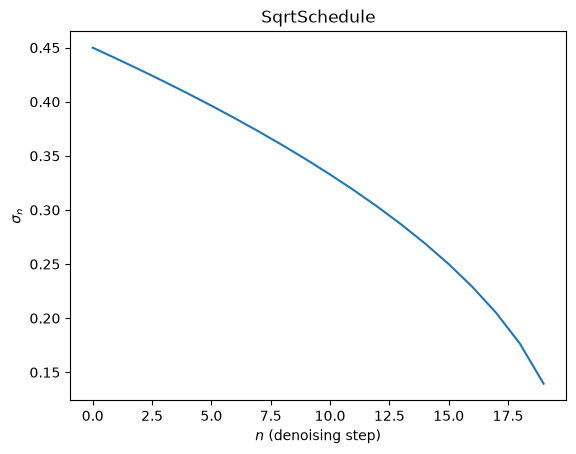

In [5]:
class SqrtSchedule(NoiseSchedule):
    """sigma_n decaying to a floor as the trajectory denoises."""

    def __init__(self, num_steps, scale=0.4, floor=0.05):
        self.num_steps = int(num_steps)
        self.scale = float(scale)
        self.floor = float(floor)

    def sigma(self, step):
        return self.floor + self.scale * np.sqrt((self.num_steps - step) / self.num_steps)


N = 20
schedule = SqrtSchedule(N)
[round(schedule(n), 4) for n in (0, 1, N // 2, N - 1)]

plt.plot([schedule(n) for n in range(N)])
plt.title("SqrtSchedule")
plt.xlabel(r"$n$ (denoising step)")
plt.ylabel(r"$\sigma_n$")

plt.show()

In [6]:
# The two batteries-included schedules.
constant = ConstantSchedule(0.3)                                  # sigma_n = sigma
tabulated = TabulatedSchedule([schedule(n) for n in range(N)])    # pre-computed, e.g. eq. (37)

print("constant     ", constant(0), constant(19))
print("tabulated    ", round(tabulated(0), 4), round(tabulated(19), 4), "len:", len(tabulated))

# The guard. Note it fires on __call__, not on sigma(), so a schedule is free to
# *store* a zero -- it just cannot be used at a step the sampler visits.
zero = ConstantSchedule(0.0)
print("sigma(0)     ", zero.sigma(0), "<- raw value, no check")
try:
    zero(0)
except ValueError as exc:
    print("schedule(0)  ", type(exc).__name__, "->", str(exc).splitlines()[0])

constant      0.3 0.3
tabulated     0.45 0.1394 len: 20
sigma(0)      0.0 <- raw value, no check
schedule(0)   ValueError -> sigma(0) = 0.0: speculation is vacuous at zero churn (the transitions become point masses, TV distance 1). See Remark 3 in the paper.


### 3.1 The schedule of the paper's experiments, eq. (37)

For the linear probability path used throughout Section 5 (derived in §4.2 below), the diffusion
coefficient is $g_t^2 = 2t/(1-t)$, so eq. (5) becomes

$$\sigma_n = \sqrt{\gamma}\,\varepsilon\, g_{1-t_n}
          = \varepsilon \sqrt{\frac{2\gamma\,(1 - t_n)}{t_n}} \tag{37}$$

Two properties worth reading off, because they decide whether speculation is worth anything:

* **$\sigma_n$ depends on the time grid and $\varepsilon$ only — not on the state.** That is what
  makes the variance *shared* between the two kernels, hence eq. (24), hence the rank-1 reduction.
  Substituting a delayed velocity into the mean changes $m^q \to m^p$ and nothing else.
* **Both ends of the grid are singular**: $\sigma_n \to \infty$ as $t_n \to 0$ and
  $\sigma_n \to 0$ as $t_n \to 1$. Experiments therefore run the grid strictly inside $(0, 1)$ —
  the paper's Gaussian-mixture setting uses $t \in [0.05, 0.98]$.

   n     t_n   sigma_n
   0   0.050    0.8407
   1   0.069    0.7107
  10   0.236    0.3470
  25   0.515    0.1872
  40   0.794    0.0982
  49   0.961    0.0386

at t_n = 1: ValueError -> sigma(2) = 0.0: speculation is vacuous at zero churn (the transitions become point masses, TV distance 1). See Remark 3 in the paper.


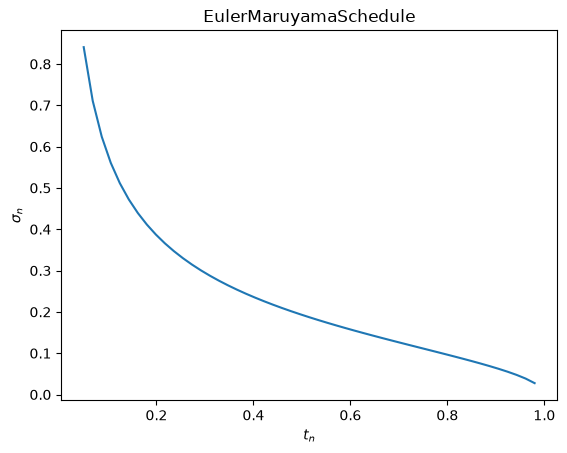

In [8]:
class EulerMaruyamaSchedule(NoiseSchedule):
    """sigma_n = eps * sqrt(2 gamma (1 - t_n) / t_n), eq. (37)."""

    def __init__(self, times, churn):
        self.times = np.asarray(times, dtype=float)     # the reverse-time grid t_0 .. t_N
        self.gamma = float(times[1] - times[0])         # gamma = 1 / N, up to the clipping
        self.eps = float(churn)

    def sigma(self, step):
        t = self.times[step]
        return self.eps * float(np.sqrt(2.0 * self.gamma * (1.0 - t) / t))


N_mix = 50
times = np.linspace(0.05, 0.98, N_mix + 1)      # clipped away from both singular endpoints
em = EulerMaruyamaSchedule(times, churn=1.0)

print(f"{'n':>4}{'t_n':>8}{'sigma_n':>10}")
for n in (0, 1, 10, 25, 40, N_mix - 1):
    print(f"{n:>4}{times[n]:>8.3f}{em(n):>10.4f}")

# what the guard is protecting you from, at the t -> 1 end
try:
    EulerMaruyamaSchedule(np.linspace(0.05, 1.0, 3), churn=1.0)(2)
except ValueError as exc:
    print()
    print("at t_n = 1:", type(exc).__name__, "->", str(exc).splitlines()[0])


plt.plot(times, [em(n) for n in range(N_mix + 1)])
plt.title("EulerMaruyamaSchedule")
plt.xlabel(r"$t_n$")
plt.ylabel(r"$\sigma_n$")

plt.show()

## 4. `TargetTransition` — the mean map $m^q_n$

**GOAL**: At step $n$, for each $u\in\mathcal{I}_n$ evaluate in parallel
$$
  m^q_{n + |u|}(\widehat{Y}_u)
$$
To do that we need to define $m^q_{t_n}(\cdot): \mathbb{N}_+ \times \mathbb{R^d} \to \mathbb{R}^d$.

We need to create a class that extends `TargetTransition` and implements `means` for a batch input of `times` $(t_{n+|u|})_{u\in\mathcal{I}_n}$ and `states` $(x_{u})_{u\in\mathcal{I}_n}$, with $t_{n+|u|}\in \mathbb{N}_+$ and $x_u\in\mathbb{R}^d$.

* `states` is a stack of shape `(no_internal_nodes, *state_shape)` — **every internal node of the round's draft
  tree at once**. The paper's Algorithm 3, line 12, evaluates $m^q_{n + |u|}(\widehat{Y}_u)$ for all $u \in \mathcal{I}(\mathcal{T}_n)$ *in parallel*, and this
  method is that line;
* `steps` is a tuple of the same length, because a node at depth $|u|$ realises step $n + |u|$ —
  different rows of the same call sit at different points of the schedule;
* the return must have `no_internal_nodes` rows, and that is checked.

For the uniform $(K, L)$ family the batch size is $|\mathcal{I}| = B/K$ (eq. 26), where
$B = K + \dots + K^L$ (eq. 12) is the proposal budget. Those belong to the tree tutorial; the
consequence for you is that `means` must be a **single batched evaluation** of your network — one
round costs one NFE regardless of how many states the tree drafted.

### Example

Before the real conversion, a target you can differentiate on paper. Take a constant vector
$c \in \mathbb{R}^d$ and a per-step coefficient $\gamma_n \in (0, 1)$, and define

$$m^q_n(y) = y + \gamma_n\,(c - y) = (1 - \gamma_n)\,y + \gamma_n c$$

Matching against eq. (5), $m^q_n(y) = y + \gamma\, b^q_{t_n}(y)$ with $\gamma = 1/N$, identifies the
reverse drift as a linear restoring force towards $c$,

$$b^q_{t_n}(y) = \frac{\gamma_n}{\gamma}\,(c - y) = N\gamma_n\,(c - y)$$

i.e. the Euler–Maruyama step of an Ornstein–Uhlenbeck reverse SDE with rate $N\gamma_n$. Beware the
name collision: the code's `gammas[n]` is $\gamma_n$, the *whole* increment coefficient
$\gamma \cdot(\text{rate})$, not the paper's step size $\gamma$.

Together with a schedule this is a complete kernel, eq. (24):

$$Y_{n+1} \mid Y_n = y \;\sim\; \mathcal{N}\!\big((1 - \gamma_n) y + \gamma_n c,\; \sigma_n^2 \mathbb{I}_d\big)$$

Writing $a_n := 1 - \gamma_n$ for the contraction factor, the chain is linear-Gaussian, so the law
of the terminal state is available in closed form:

$$Y_N \mid Y_0 = y_0 \;\sim\; \mathcal{N}\!\left(
\Big(\textstyle\prod_{n=0}^{N-1} a_n\Big) y_0 + \Big(1 - \textstyle\prod_{n=0}^{N-1} a_n\Big) c,\;\;
\sum_{n=0}^{N-1} \sigma_n^2 \prod_{m=n+1}^{N-1} a_m^2 \;\mathbb{I}_d \right)$$

using $\sum_n \gamma_n \prod_{m>n} a_m = 1 - \prod_n a_n$. That closed form is what the sampler
tutorial checks the sampler's output against — with an exact rule, speculation must not change it.

**The two array lines.** `self.gammas[list(steps)]` picks $\gamma_{n_i}$ *per row*, because rows of
one call sit at different depths of the tree and therefore at different steps. The
`reshape(-1, 1, 1, ...)` then broadcasts that column against whatever `state_shape` is — `(d,)`
here, `(3, 32, 32)` or `(16, 64, 64)` for a real model — so the same two lines work at any state
rank.

**Its $\delta$, in closed form.** Freeze the delayed drift at $(n', \widetilde{y})$; then
$m^p_n(y) = y + \gamma_{n'}(c - \widetilde{y})$, so

$$\delta = \frac{\lVert \gamma_n (c - y) - \gamma_{n'} (c - \widetilde{y})\rVert}{\sigma_n}$$

which names the two sources of staleness explicitly: the coefficient is read at the wrong step
($\gamma_{n'}$ instead of $\gamma_n$) and the drift at the wrong state ($\widetilde{y}$ instead of
$y$). Section 6.2 measures exactly this as the round descends.

In [42]:
class LinearReverseKernel(TargetTransition):
    """A stand-in for the expensive network: m^q_n(y) = y + gamma_n (c - y).

    This is eq. (5) with a linear reverse drift, b^q_{t_n}(y) = (gamma_n / gamma)(c - y):
    one drift evaluation folded into a mean. Every Euler-Maruyama reverse step has
    this shape. Here the drift is linear so every number below can be checked by hand;
    in production the drift is a call to a denoiser. Section 4.2 builds the real thing.
    """

    def __init__(self, center, gammas):
        super().__init__()                      # sets up the NFE counters
        self.center = np.asarray(center, dtype=float)
        self.gammas = np.asarray(gammas, dtype=float)

    def means(self, states, steps):
        gamma = self.gammas[list(steps)].reshape(-1, *([1] * (states.ndim - 1)))
        return states + gamma * (self.center - states)


dim = 4
no_internal_nodes = 5
target = LinearReverseKernel(center=np.zeros(dim), gammas=np.linspace(0.05, 0.25, N))
states = rng.standard_normal((no_internal_nodes, dim))
steps = np.arange(no_internal_nodes)

states_shape = states.shape
print(f"states, shape={states_shape}:\n", states)
print("----------------------------------------------------------------------------------------")
print(f"steps, shape={steps.shape}:\n", steps)
print("----------------------------------------------------------------------------------------\n")
# three nodes of one draft tree, at three different depths -> three different steps
print("Use `TargetTransition.means` --> target.means(states, steps)\n It does NOT count the number of function evaluations (NFE):\n\n", target.means(states, steps))
print("\n - No. of function evaluations (NFE) so far:", target.num_calls)
print("----------------------------------------------------------------------------------------\n")
print("Use `TargetTransition.__call__` --> target(states, steps)\n It DOES count the number of function evaluations (NFE):\n\n", target(states, steps))
print("\n - No. of function evaluations (NFE) so far:", target.num_calls)



states, shape=(5, 4):
 [[-1.34308865 -0.43051197  0.26135085 -0.01791682]
 [-0.19199322 -0.66587608 -0.2583831  -0.77419782]
 [-2.42183301 -1.19450844  0.47565294  1.55707796]
 [ 1.81358017  0.09675174  0.89338362  0.90797791]
 [-0.69225918 -1.69793983  0.03088732 -1.762201  ]]
----------------------------------------------------------------------------------------
steps, shape=(5,):
 [0 1 2 3 4]
----------------------------------------------------------------------------------------

Use `TargetTransition.means` --> target.means(states, steps)
 It does NOT count the number of function evaluations (NFE):

 [[-1.27593422 -0.40898637  0.2482833  -0.01702098]
 [-0.18037258 -0.62557305 -0.24274413 -0.72733848]
 [-2.24975541 -1.10963547  0.44185655  1.44644347]
 [ 1.66563021  0.08885884  0.82050233  0.83390603]
 [-0.62849847 -1.54155064  0.02804243 -1.59989301]]

 - No. of function evaluations (NFE) so far: 0
----------------------------------------------------------------------------------

### 4.1 Where the NFEs are counted

The paper's cost metric is the number of neural function evaluations, one batched call per round.
`TargetTransition.__call__` maintains the counters; `means` does not. Call the instance.

In [57]:
target.reset_stats()

target(states, steps)          # one batched call, no_internal_nodes states
print("num_calls  (NFEs, the paper's cost metric) ", target.num_calls)
print("num_states (batch volume, not NFEs)        ", target.num_states)
print()

target(states[:1], (7,))            # another call, one state

print("num_calls  (NFEs, the paper's cost metric) ", target.num_calls)
print("num_states (batch volume, not NFEs)        ", target.num_states)
print()

target.reset_stats()
target(states, steps)  
print("-"*60)        # one batched call, no_internal_nodes states
print("After `reset_stats()` and one batched call:")
print("num_calls  (NFEs, the paper's cost metric) ", target.num_calls)
print("num_states (batch volume, not NFEs)        ", target.num_states)
print()

print("-"*60) 
target.means(states, steps)    # bypasses the accounting -- don't do this in a model
print("after a raw .means() call                  ", target.num_calls, target.num_states)

num_calls  (NFEs, the paper's cost metric)  1
num_states (batch volume, not NFEs)         5

num_calls  (NFEs, the paper's cost metric)  2
num_states (batch volume, not NFEs)         6

------------------------------------------------------------
After `reset_stats()` and one batched call:
num_calls  (NFEs, the paper's cost metric)  1
num_states (batch volume, not NFEs)         5

------------------------------------------------------------
after a raw .means() call                   1 5


In [62]:
# The row-count check catches the most common modelling bug: a means() that
# collapses the batch (an accidental reduction over rows, or a squeeze). Without it
# the sampler would silently verify the wrong states.
class BrokenTarget(TargetTransition):
    def means(self, states, steps):
        return states.mean(axis=0, keepdims=True)


try:
    BrokenTarget()(states, steps)
except ValueError as exc:
    print(type(exc).__name__, ":", exc)

ValueError : BrokenTarget.means returned 1 rows for 5 states


### 4.2 Worked conversion: a rectified-flow model, eqs. (28)–(38)

Real models rarely hand you $b^q_t$ directly. Appendix D.2 works through the case the paper needed
for Stable Diffusion 3 — a **flow-matching** model, which parameterises a probability-flow ODE
whose transitions are deterministic point masses. Speculation is vacuous there (total variation
distance one), so the conversion exhibits the model as a member of the reverse-SDE family (2) that
shares its marginals, and lands on a genuinely Gaussian transition kernel.

**Interpolant.** With $X_0 \sim p_{\text{data}}$ and $\xi \sim \mathcal{N}(0, \mathbb{I}_d)$
independent, the data is perturbed along the linear interpolant

$$X_t = \alpha_t X_0 + \beta_t \xi, \qquad \alpha_t = 1 - t, \quad \beta_t = t \tag{28}$$

so $X_0 \sim p_{\text{data}}$ and $X_1 \sim \mathcal{N}(0, \mathbb{I}_d)$.

**Velocity.** Along (28) the velocity is constant, $\mathrm{d}X_t/\mathrm{d}t = \xi - X_0$, and the
network is trained to regress the *marginal* velocity field

$$v_t(x) := \mathbb{E}\!\left[\frac{\mathrm{d}X_t}{\mathrm{d}t} \,\middle|\, X_t = x\right] \tag{29}$$
$$= \mathbb{E}[\xi \mid X_t = x] - \mathbb{E}[X_0 \mid X_t = x] \tag{30}$$

**Drift and diffusion coefficient.** Any affine interpolant of the form (28) obeys a linear SDE
$\mathrm{d}X_t = f_t X_t \,\mathrm{d}t + g_t\,\mathrm{d}B_t$, and inverting the relations for the
conditional mean and variance gives

$$f_t = \frac{1}{\alpha_t}\frac{\mathrm{d}\alpha_t}{\mathrm{d}t},
\qquad
g_t^2 = 2\beta_t\left(\frac{\mathrm{d}\beta_t}{\mathrm{d}t} - f_t \beta_t\right) \tag{31}$$

which for $\alpha_t = 1-t$, $\beta_t = t$ evaluates to

$$f_t(x) = -\frac{x}{1-t}, \qquad g_t^2 = \frac{2t}{1-t} \tag{32}$$

**Score.** Taking conditional expectations in (28) gives
$x = (1-t)\mathbb{E}[X_0 \mid X_t = x] + t\,\mathbb{E}[\xi \mid X_t = x]$; eliminating
$\mathbb{E}[X_0 \mid X_t = x]$ from (30) leaves

$$v_t(x) = \frac{\mathbb{E}[\xi \mid X_t = x] - x}{1 - t} \tag{33}$$

and combining it with $s_t(x) = -\mathbb{E}[\xi \mid X_t = x]/\beta_t$ yields the score in terms of
the quantity the network actually outputs:

$$s_t(x) = -\frac{x + (1-t)\,v_t(x)}{t} \tag{34}$$

**Reverse drift.** Substituting $f_{1-t}$, $g^2_{1-t}$ and (34) into (3):

$$b^q_t(x) = -(1 + \varepsilon^2)\, v_{1-t}(x) - \varepsilon^2 \frac{x}{t} \tag{35}$$

**Transition kernel.** Finally, the Euler–Maruyama step (4) on the grid $t_n = n\gamma$ gives
$\mathbb{Q}_n(\cdot \mid y) = \mathcal{N}(m^q_n(y), \sigma_n^2 \mathbb{I}_d)$ with

$$m^q_n(y) = y - \gamma\left[(1 + \varepsilon^2)\, v_{1-t_n}(y) + \varepsilon^2 \frac{y}{t_n}\right] \tag{36}$$
$$\sigma_n = \sqrt{\gamma}\,\varepsilon\, g_{1-t_n} = \varepsilon\sqrt{\frac{2\gamma(1-t_n)}{t_n}} \tag{37}$$

**Timestep shift.** SD3 is trained at $1024 \times 1024$ and its noise schedule is resolution
dependent, so generating at $512 \times 512$ applies the shift

$$t \longmapsto \frac{\kappa\,t}{1 + (\kappa - 1)\,t}, \qquad \kappa = 3.0 \tag{38}$$

to the uniform grid before evaluating $v_\theta$. The conversion above is unaffected, since (34)
and (35) hold pointwise in $t$.

Eqs. (36)–(37) are exactly a `TargetTransition` and a `NoiseSchedule`. Below they are implemented
against an analytic velocity field, so every step can be checked numerically.

In [64]:
# A Gaussian-mixture data distribution, where v_t and s_t are available in closed
# form -- the setting of Section 5.1, standing in for the network v_theta.
d_mix, C = 8, 5
mu = rng.uniform(-2, 2, size=(C, d_mix))         # component means
sd = rng.uniform(0.10, 0.25, size=C)             # component scales


def posterior(x, t):
    """Weights, offsets and variances of p_t under the interpolant (28)."""
    m = (1.0 - t) * mu                                  # (C, d)
    V = (1.0 - t) ** 2 * sd**2 + t**2                   # (C,)
    diff = x[:, None, :] - m[None, :, :]                # (rows, C, d)
    logw = -0.5 * (diff**2).sum(-1) / V - 0.5 * d_mix * np.log(V)
    logw -= logw.max(axis=1, keepdims=True)
    w = np.exp(logw)
    return w / w.sum(axis=1, keepdims=True), diff, V


def e_xi(x, t):                                          # E[xi | X_t = x]
    w, diff, V = posterior(x, t)
    return (w[:, :, None] * (t / V)[None, :, None] * diff).sum(axis=1)


def e_x0(x, t):                                          # E[X_0 | X_t = x]
    w, diff, V = posterior(x, t)
    per = mu[None, :, :] + ((1.0 - t) * sd**2 / V)[None, :, None] * diff
    return (w[:, :, None] * per).sum(axis=1)


def velocity(x, t):                                      # eq. (30)
    return e_xi(x, t) - e_x0(x, t)


def score(x, t):                                         # grad log p_t, analytic
    w, diff, V = posterior(x, t)
    return (w[:, :, None] * (-diff / V[None, :, None])).sum(axis=1)


x = rng.standard_normal((5, d_mix))
t = 0.4

print("eq. (30) vs eq. (33)  -- two forms of the velocity")
print("   max |v - (E[xi|x] - x)/(1-t)| =",
      float(np.abs(velocity(x, t) - (e_xi(x, t) - x) / (1.0 - t)).max()))

print()
print("eq. (34) -- score recovered from the velocity, against the analytic score")
print("   max |s_t(x) + (x + (1-t) v_t(x))/t| =",
      float(np.abs(score(x, t) + (x + (1.0 - t) * velocity(x, t)) / t).max()))

eq. (30) vs eq. (33)  -- two forms of the velocity
   max |v - (E[xi|x] - x)/(1-t)| = 1.3322676295501878e-15

eq. (34) -- score recovered from the velocity, against the analytic score
   max |s_t(x) + (x + (1-t) v_t(x))/t| = 3.552713678800501e-15


In [65]:
class RectifiedFlowKernel(TargetTransition):
    """eq. (36): m^q_n(y) = y - gamma [ (1 + eps^2) v_{1-t_n}(y) + eps^2 y / t_n ].

    `velocity_fn(x, tau)` stands in for v_theta. Note the time argument: the reverse
    process at t_n reads the velocity field at interpolant time 1 - t_n.
    """

    def __init__(self, velocity_fn, times, churn=1.0):
        super().__init__()
        self.velocity_fn = velocity_fn
        self.times = np.asarray(times, dtype=float)
        self.gamma = float(times[1] - times[0])
        self.eps = float(churn)

    def drift(self, x, t):
        """eq. (35), for inspection -- the sampler never asks for this."""
        return -(1.0 + self.eps**2) * self.velocity_fn(x, 1.0 - t) - self.eps**2 * x / t

    def means(self, states, steps):
        out = np.empty_like(states)
        for step in sorted(set(steps)):              # one vectorised group per step
            idx = [i for i, s in enumerate(steps) if s == step]
            t = self.times[step]
            y = states[idx]
            out[idx] = y - self.gamma * (
                (1.0 + self.eps**2) * self.velocity_fn(y, 1.0 - t) + self.eps**2 * y / t
            )
        return out


churn = 1.0
times = np.linspace(0.05, 0.98, N_mix + 1)      # clipped away from both singular endpoints
mix_target = RectifiedFlowKernel(velocity, times, churn=churn)
mix_schedule = EulerMaruyamaSchedule(times, churn)

y = rng.standard_normal((4, d_mix))
n = 10

print("eq. (5) and eq. (36) are the same map:")
print("   max |m^q_n(y) - (y + gamma b^q_{t_n}(y))| =",
      float(np.abs(mix_target(y, (n,) * 4) - (y + mix_target.gamma * mix_target.drift(y, times[n]))).max()))
print()
print(f"sigma_{n} from eq. (37): {mix_schedule(n):.4f}")

eq. (5) and eq. (36) are the same map:
   max |m^q_n(y) - (y + gamma b^q_{t_n}(y))| = 0.0

sigma_10 from eq. (37): 0.3470


That is a complete model: `RectifiedFlowKernel` is $m^q_n$ and `EulerMaruyamaSchedule` is
$\sigma_n$, and together they *are* $\mathbb{Q}_n$ of eq. (24). Simulating the chain (6) with them
— a Gaussian draw per step, eq. (4) — should reproduce the data distribution:

In [10]:
def simulate_reference_chain(kernel, sched, trials=2000, seed=3):
    """The non-speculative baseline: Y_{n+1} = m^q_n(Y_n) + sigma_n xi, eq. (4)."""
    r = np.random.default_rng(seed)
    y = r.standard_normal((trials, d_mix))                   # Y_0 ~ q_0
    for step in range(len(sched.times) - 1):
        y = kernel.means(y, (step,) * trials) + sched(step) * r.standard_normal(y.shape)
    return y


samples = simulate_reference_chain(mix_target, mix_schedule)
assign = np.linalg.norm(samples[:, None, :] - mu[None], axis=2).argmin(axis=1)

print("component occupancy   ", (np.bincount(assign, minlength=C) / len(samples)).round(3),
      " (uniform mixture => ~0.2 each)")
print("mean distance to its component ", round(float(np.linalg.norm(samples - mu[assign], axis=1).mean()), 3))
print("expected, ~ s * sqrt(d)        ", round(float(sd.mean() * np.sqrt(d_mix)), 3))

component occupancy    [0.22  0.196 0.184 0.204 0.196]  (uniform mixture => ~0.2 each)
mean distance to its component  0.436
expected, ~ s * sqrt(d)         0.442


## 5. `ProposalTransition` — the mean map $m^p_n$

Same `means` signature, but called once per tree *level* during drafting, with every parent at
that level. Appendix C writes the drafting law explicitly: at level $\ell$ of a round starting at
step $n$, the children of each parent $u$ are drawn i.i.d. from

$$\widehat{Y}_v \sim \mathcal{N}\!\big(\tilde m^p_\ell(\widehat{Y}_u),\; \sigma^2_{n + \ell - 1}\mathbb{I}_d\big),
\qquad v \in \mathcal{C}(u), \quad |u| = \ell - 1$$

The proposal is cheap by assumption, so nothing counts it.

The three lifecycle hooks exist because the interesting proposals are stateful:

| hook | when | why |
| --- | --- | --- |
| `on_round_start(step, root_state)` | once per round, before drafting | a delayed drift needs to know where the round starts, i.e. $Y_n$ |
| `on_verified(step, state, target_mean)` | per committed node, after its target mean was computed | the channel that makes root-drift prefetching possible |
| `reset()` | at the start of each `sample()` | drop per-run state |

A stateless proposal inherits all three as no-ops. Two are shipped, and neither is a model:

In [67]:
y = rng.standard_normal((2, dim))

identity = IdentityProposal()       # m^p(y) = y: the worst useful proposal, and free
mirror = MirrorProposal(target)     # m^p = m^q: a perfect proposal, delta = 0 everywhere

print("identity == y        ", np.allclose(identity.means(y, (3, 3)), y))
print("mirror   == target   ", np.allclose(mirror.means(y, (3, 3)), target(y, (3, 3))))
print("stateful flags       ", identity.stateful, mirror.stateful)

identity == y         True
mirror   == target    True
stateful flags        False False


#### Stateless vs stateful
A stateless proposal is a pure function of its arguments:
```python
identity.means(y, (3, 3))     # same y, same steps -> same answer, always, forever
```
A stateful one is not: the same y gives a different answer depending on which hooks fired before it.
```python
p = DelayedDriftProposal(target)
p.reset()
p.on_round_start(0, root_a);  p.means(y, (0,))   # uses the drift frozen at root_a
p.on_round_start(0, root_b);  p.means(y, (0,))   # different answer, same arguments
p2 = DelayedDriftProposal(target); p2.reset(); p2.means(y, (0,))   # RuntimeError: no drift yet
```

Exactly one place in the library — `StatelessBatchedProposal.__init__` (batched.py:79) — which raises rather than accept a stateful proposal. Nothing in the scalar sampler looks at it, which is why it seems inert in this notebook: with one trajectory, a cache is fine.

Under the batched sampler, one proposal instance serves rows from many trajectories sitting at different steps $n_i$. A shared cache would hand every row trajectory 0's frozen drift: the returned means are still the right shape, still finite, still plausible Gaussian centres — so nothing crashes, and you get silently wrong samples. Python cannot detect "this object has meaningful hidden state", so the author asserts it in one line and the batched path can refuse loudly.

#### NFEs check

In [68]:
# MirrorProposal is a *test device*, not a model: it reaches for the target, so every
# drafting level it serves costs a real NFE. Useful for isolating sampler bugs from
# coupling bugs (delta = 0 => everything accepts); useless in production.
target.reset_stats()
mirror.means(y, (3, 3))
print("NFEs spent by one mirror drafting level:", target.num_calls)

NFEs spent by one mirror drafting level: 1


### 5.1 Writing your own

The paper mentions two proposal mechanisms (Section 2). The first trains a **lightweight diffusion
model** to approximate the target reverse drift; that is stateless, so it is just a `means`:

In [13]:
class CoarseDrift(ProposalTransition):
    """A stand-in for a distilled draft network: the target's drift, scaled."""

    def __init__(self, center, gammas, quality=0.8):
        self.center = np.asarray(center, dtype=float)
        self.gammas = np.asarray(gammas, dtype=float)
        self.quality = float(quality)

    def means(self, states, steps):
        gamma = self.gammas[list(steps)].reshape(-1, *([1] * (states.ndim - 1)))
        return states + self.quality * gamma * (self.center - states)


coarse = CoarseDrift(target.center, target.gammas)
mu_q = target(y, (10, 10))
mu_p = coarse.means(y, (10, 10))

sigma = schedule(10)
delta = np.linalg.norm(mu_q - mu_p, axis=1) / sigma          # eq. (8)
print("delta per row:", delta.round(4))
print("implied per-step acceptance of a maximal coupling, eq. (16):",
      (2.0 * np.array([standard_normal_sf(dl / 2.0) for dl in delta])).round(4))

delta per row: [0.143  0.2044]
implied per-step acceptance of a maximal coupling, eq. (16): [0.943  0.9186]


Two things to note about that acceptance number. It is

$$\mathbb{P}\big(\exists k \in \{1, \dots, K\} : Y = \widehat{Y}_k\big) = 2\overline{\Phi}\!\left(\frac{\delta}{2}\right) \tag{16}$$

the $K = 1$ specialisation of D-GRS's general acceptance probability, and the *optimal* value for a
maximal coupling of a single proposal — what RMC achieves. And it is a function of $\delta$ alone,
so the model you write in this notebook fully determines the speedup ceiling before any coupling
exists. (For $K > 1$ the general form is eq. (14)–(15), in the verifier tutorial.)

## 6. `DelayedDriftProposal` — eq. (7) with root-drift prefetching

The second proposal mechanism, and the one the paper adopts throughout, needs no second network.
Because the target mean is $m^q_n(y) = y + \gamma\, b^q_{t_n}(y)$, the **drift increment is
recoverable from means alone**:

$$\gamma\, b^q_{t_{n'}}(\widetilde{Y}) = m^q_{n'}(\widetilde{Y}) - \widetilde{Y}$$

The proposal freezes that increment at the root of the round and reuses it at every depth, which is
Appendix C's

$$\tilde m^p_{n'}(y) = y + \gamma\, b^q_{t_n}(Y_n) \quad \text{for every step } n' \le L \text{ of the round}$$

Note the consequence: `DelayedDriftProposal` never touches your drift, your score or your network —
only means it has already been handed.

In [70]:
proposal = DelayedDriftProposal(target)     # prefetch=True is the paper's default
target.reset_stats()
proposal.reset()

root = rng.standard_normal(dim)
proposal.on_round_start(0, root)            # the one unavoidable warm-up call, at n = 0
print("warm-up NFEs:", target.num_calls)

# At the root the frozen drift is the exact one, so m^p = m^q there and delta = 0.
print("exact at the root:", np.allclose(proposal.means(root[None], (0,)), target.means(root[None], (0,))))

# Away from the root it is a frozen-drift approximation -- that gap is delta, eq. (8).
elsewhere = root + 0.5 * rng.standard_normal((3, dim))
gap = proposal.means(elsewhere, (1, 1, 1)) - target.means(elsewhere, (1, 1, 1))
print("delta at depth 1: ", (np.linalg.norm(gap, axis=1) / schedule(1)).round(4))

warm-up NFEs: 1
exact at the root: True
delta at depth 1:  [0.163  0.1715 0.0876]


In [81]:
print(root)
print(root.shape)

print()

print(root[None])
print(root[None].shape)

[-1.81487228  1.73860211  1.26881527  0.57306599]
(4,)

[[-1.81487228  1.73860211  1.26881527  0.57306599]]
(1, 4)


### 6.1 Root-drift prefetching

Taken literally, eq. (7) costs **one extra target call per round**: the drafting phase needs
$b^q_{t_n}(Y_n)$ at the root of every round, on top of the one call verification already spends.
Appendix C removes it:

> When the delayed-drift is used as proposal, the drafting phase requires evaluating
> $b^q_{t_n}(Y_n)$ at the root of every round. Following De Bortoli et al. (2025), we avoid this by
> reusing a drift already computed during the preceding round: $b^q_{t_n}(Y_n)$ is replaced by
> $b^q_{t_{n'}}(\widetilde{Y})$ for some pair $(n', \widetilde{Y})$ whose drift is already available.

`on_verified` is that channel. The target mean at a node just verified was paid for in Phase 2 and
is the freshest drift in existence, so the proposal caches it for the next round. Here is a round
in slow motion, doing by hand what the sampler does:

#### `Prefetch = False`

In [82]:
proposal = DelayedDriftProposal(target, prefetch=False)     # prefetch=False
target.reset_stats()
proposal.reset()

state = root
for n in (0, 1, 2):
    before = target.num_calls
    proposal.on_round_start(n, state)                    # warms up only at n = 0
    warmup = target.num_calls - before

    drafted = proposal.means(state[None], (n,))[0]       # drafting uses the frozen drift
    committed = drafted + schedule(n) * rng.standard_normal(dim)

    mean_at_parent = target(state[None], (n,))[0]        # verification pays for this anyway
    proposal.on_verified(n, state, mean_at_parent)       # ... so hand it back: prefetch

    print(f"round n={n}  NFEs charged to the proposal: {warmup}   total so far: {target.num_calls}")
    state = committed

round n=0  NFEs charged to the proposal: 1   total so far: 2
round n=1  NFEs charged to the proposal: 1   total so far: 4
round n=2  NFEs charged to the proposal: 1   total so far: 6


#### `Prefetch = True`

In [83]:
proposal = DelayedDriftProposal(target, prefetch=True)     # prefetch=False
target.reset_stats()
proposal.reset()

state = root
for n in (0, 1, 2):
    before = target.num_calls
    proposal.on_round_start(n, state)                    # warms up only at n = 0
    warmup = target.num_calls - before

    drafted = proposal.means(state[None], (n,))[0]       # drafting uses the frozen drift
    committed = drafted + schedule(n) * rng.standard_normal(dim)

    mean_at_parent = target(state[None], (n,))[0]        # verification pays for this anyway
    proposal.on_verified(n, state, mean_at_parent)       # ... so hand it back: prefetch

    print(f"round n={n}  NFEs charged to the proposal: {warmup}   total so far: {target.num_calls}")
    state = committed

round n=0  NFEs charged to the proposal: 1   total so far: 2
round n=1  NFEs charged to the proposal: 0   total so far: 3
round n=2  NFEs charged to the proposal: 0   total so far: 4


Only the warm-up cost an extra call: from $n = 1$ on, `on_round_start` finds an increment already
in hand. Exactly **one** warm-up target call for a whole run, at $n = 0$, and it is counted in
`target_calls`.

`prefetch=False` gives up the trick and re-evaluates the target at every round's root. It costs one
extra NFE per round, but the drift is one round fresher — useful for isolating how much of the
speedup is proposal *quality* versus proposal *cost*:

In [16]:
for prefetch in (True, False):
    p = DelayedDriftProposal(target, prefetch=prefetch)
    target.reset_stats()
    p.reset()
    st = root
    for n in range(5):
        p.on_round_start(n, st)
        st = p.means(st[None], (n,))[0] + schedule(n) * rng.standard_normal(dim)
        p.on_verified(n, st, target(st[None], (n,))[0])
    # 5 rounds, each paying 1 NFE for verification in this hand-rolled loop
    print(f"prefetch={prefetch!s:5}  NFEs over 5 rounds: {target.num_calls}")

prefetch=True   NFEs over 5 rounds: 6
prefetch=False  NFEs over 5 rounds: 10


### 6.2 The cost of reusing a drift

The frozen increment ages as the round descends: at level $\ell$ the drafted state has moved $\ell - 1$ steps away from the state the drift was evaluated at, so $\delta$ grows with depth. That is what bounds the useful lookahead $L$ — the paper's Appendix D.1 makes the same point from the acceptance side, and Figure 7 shows the speedup saturating in $L$ while continuing to rise in $K$.

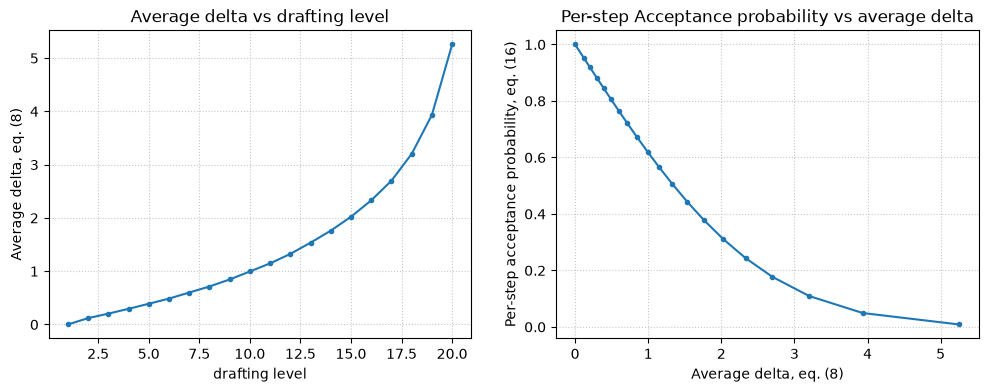

In [105]:
def drift_age_profile(levels=6, trials=400):
    """Mean delta at each depth of a round, averaged over independent roots."""
    proposal = DelayedDriftProposal(target, prefetch=False)
    deltas = np.zeros(levels)
    for _ in range(trials):
        proposal.reset()
        state = rng.standard_normal(dim)
        proposal.on_round_start(0, state)
        for level in range(1, levels + 1):
            step = level - 1
            mu_p = proposal.means(state[None], (step,))[0]     # frozen at the root
            mu_q = target.means(state[None], (step,))[0]       # the truth at this node
            deltas[level - 1] += np.linalg.norm(mu_q - mu_p) / schedule(step)     # eq. (8)
            state = mu_p + schedule(step) * rng.standard_normal(dim)           # descend
    return deltas / trials


n_levels, n_trials = 20, 400
levels = np.arange(1, n_levels + 1)
deltas = drift_age_profile(n_levels, n_trials)
alphas = 2.0 * np.array([standard_normal_sf(dl / 2.0) for dl in deltas])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(levels, deltas, marker='.')
ax[0].set_xlabel("drafting level")
ax[0].set_ylabel("Average delta, eq. (8)")
ax[0].set_title("Average delta vs drafting level")
ax[0].grid(linestyle=':', alpha=0.7)

ax[1].plot(deltas, alphas, marker='.')
ax[1].set_xlabel("Average delta, eq. (8)")
ax[1].set_ylabel("Per-step acceptance probability, eq. (16)")
ax[1].set_title("Per-step Acceptance probability vs average delta")
ax[1].grid(linestyle=':', alpha=0.7)
plt.show()

### 6.3 From $\delta$ to a speedup ceiling

Appendix D.1 closes the loop. If the per-step acceptance probability of the coupling is $\alpha$,
fixed across steps, the expected length of the accepted prefix of a chain of $n$ drafted states is

$$\sum_{i=1}^{n} \alpha^i = \frac{\alpha\,(1 - \alpha^n)}{1 - \alpha}
\;\xrightarrow[n \to \infty]{}\; \frac{\alpha}{1 - \alpha}$$

and since each round commits the accepted prefix *together with one resampled state* at the cost of
a single target evaluation, the number of committed steps per NFE is bounded above by

$$\frac{1}{1 - \alpha}$$

So the model you wrote in sections 3–4, plus the proposal in section 6, already determines the
ceiling — before a single line of coupling exists:

   delta   alpha, eq. (16)   ceiling 1/(1-alpha)


/var/folders/qf/743nl31j43x225lgt_db1thc0000gn/T/ipykernel_34242/416749650.py:4: RuntimeWarning: divide by zero encountered in divide
  upper_bounds = np.where(per_step_alphas >= 1.0, np.inf, (1.0 / (1.0 - per_step_alphas)).round(2))


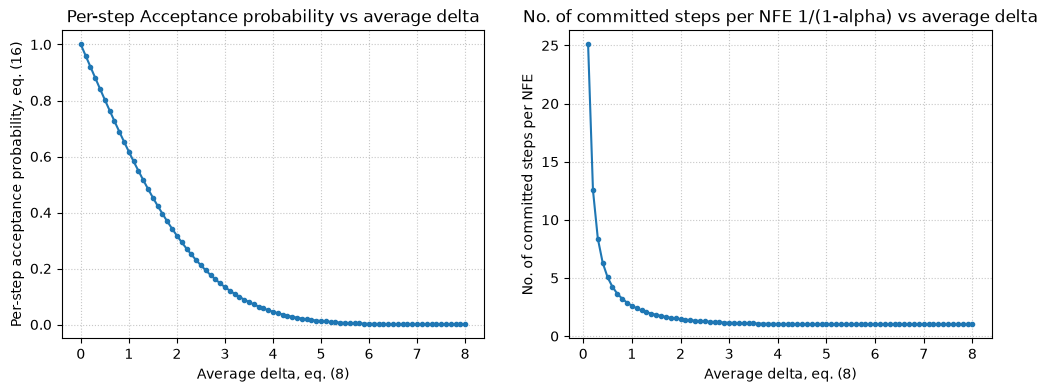

In [130]:
print(f"{'delta':>8}{'alpha, eq. (16)':>18}{'ceiling 1/(1-alpha)':>22}")
deltas = np.arange(0.0, 8.1, 0.1)
per_step_alphas = 2.0 * np.array([standard_normal_sf(dl / 2.0) for dl in deltas])
upper_bounds = np.where(per_step_alphas >= 1.0, np.inf, (1.0 / (1.0 - per_step_alphas)).round(2))
# for dl in deltas:
#     alpha = 2.0 * standard_normal_sf(dl / 2.0)
#     ceiling = "inf" if alpha >= 1.0 else f"{1.0 / (1.0 - alpha):.2f}x"
#     print(f"{dl:>8.2f}{alpha:>18.3f}{ceiling:>22}")

# print()
# print(f"this model's mean delta over a round of depth 6: {profile.mean():.3f}"
#       f"  ->  alpha {2.0 * standard_normal_sf(profile.mean() / 2.0):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(deltas, per_step_alphas, marker='.')
ax[1].plot(deltas, upper_bounds, marker='.')

ax[0].set_xlabel("Average delta, eq. (8)")
ax[0].set_ylabel("Per-step acceptance probability, eq. (16)")
ax[0].set_title("Per-step Acceptance probability vs average delta")
ax[0].grid(linestyle=':', alpha=0.7)

ax[1].set_xlabel("Average delta, eq. (8)")
ax[1].set_ylabel("No. of committed steps per NFE") 
ax[1].set_title("No. of committed steps per NFE 1/(1-alpha) vs average delta")
ax[1].grid(linestyle=':', alpha=0.7)

plt.show()

## 7. The churn parameter $\varepsilon$, and why more noise is not simply better

$\varepsilon$ appears in *both* halves of $\delta = \lVert m^q_n - m^p_n\rVert / \sigma_n$, and the
paper is explicit that the net effect does not go one way:

> **Remark 3 (continued).** Its effect on acceptance is not monotone: raising $\varepsilon$
> increases the denominator of $\delta = \lVert m^q_n - m^p_n\rVert/\sigma_n$, but it also increases
> the numerator, both through the factor $1 + \varepsilon^2$ in (36) and through the larger
> displacement of the drafted states from the point at which the delayed velocity was evaluated.

Both mechanisms are visible in the rectified-flow kernel built in §4.2. The sweep below freezes the
drift at a round's root, descends two levels, and reports the numerator and denominator separately:

   eps   sigma_n   ||m^q - m^p||    delta   alpha, eq. (16)
  0.10     0.073           0.005    0.073             0.971
  0.15     0.109           0.010    0.088             0.965
  0.20     0.145           0.016    0.109             0.957
  0.25     0.181           0.024    0.133             0.947
  0.30     0.218           0.035    0.160             0.936
  0.35     0.254           0.049    0.191             0.924
  0.40     0.290           0.066    0.226             0.910
  0.45     0.326           0.086    0.264             0.895
  0.50     0.363           0.111    0.307             0.878
  0.55     0.399           0.141    0.353             0.860
  0.60     0.435           0.176    0.404             0.840
  0.65     0.471           0.217    0.459             0.818
  0.70     0.508           0.264    0.520             0.795
  0.75     0.544           0.318    0.585             0.770
  0.80     0.580           0.380    0.655             0.743
  0.85     0.616           0.450    0.73

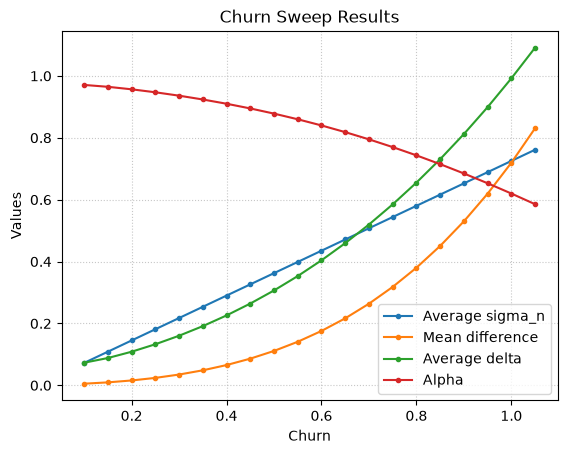

In [137]:
def churn_sweep(eps_values=(0.25, 0.5, 1.0, 2.0), levels=3, trials=200, seed=7):
    print(f"{'eps':>6}{'sigma_n':>10}{'||m^q - m^p||':>16}{'delta':>9}{'alpha, eq. (16)':>18}")
    sigmas, mean_diff, deltas, alphas = [], [], [], []
    for eps in eps_values:
        r = np.random.default_rng(seed)
        tgt = RectifiedFlowKernel(velocity, times, churn=eps)
        sch = EulerMaruyamaSchedule(times, eps)
        num = den = 0.0
        for _ in range(trials):
            state = r.standard_normal(d_mix)
            increment = tgt.means(state[None], (0,))[0] - state        # freeze at the root
            for level in range(1, levels + 1):
                step = level - 1
                mu_p = state + increment
                mu_q = tgt.means(state[None], (step,))[0]
                num += float(np.linalg.norm(mu_q - mu_p))
                den += sch(step)
                state = mu_p + sch(step) * r.standard_normal(d_mix)
        num /= trials * levels
        den /= trials * levels
        sigmas.append(den)
        delta = num / den
        deltas.append(delta)
        mean_diff.append(num)
        alphas.append(2.0 * standard_normal_sf(delta / 2.0))
        print(f"{eps:>6.2f}{den:>10.3f}{num:>16.3f}{delta:>9.3f}"
              f"{2.0 * standard_normal_sf(delta / 2.0):>18.3f}")

    plt.plot(eps_values, sigmas, marker='.', label='Average sigma_n')
    plt.plot(eps_values, mean_diff, marker='.', label='Mean difference')
    plt.plot(eps_values, deltas, marker='.', label='Average delta')
    plt.plot(eps_values, alphas, marker='.', label='Alpha')

    plt.xlabel('Churn')
    plt.ylabel('Values')
    plt.title('Churn Sweep Results')
    plt.legend()
    plt.grid(linestyle=':', alpha=0.7)

eps_values = np.arange(0.1, 1.1, 0.05)
churn_sweep(eps_values)

The denominator $\sigma_n$ grows linearly in $\varepsilon$ (eq. 37), but the numerator grows faster: the drift itself carries a factor $1 + \varepsilon^2$ (eq. 36) *and* the noisier steps push each drafted state further from the point where the delayed velocity was frozen, so the frozen increment is a worse approximation. On this model the second effect wins and $\delta$ increases with churn — but that is a statement about this model, not a law. The paper's experiments show the same direction (Figure 4: higher churn degrades speedup for both RMC and D-GRS), which is why **$\delta$ is something you measure**, with the delta probe of the verifier tutorial, rather than something you predict from $\sigma$.

## 8. `stateful`, and why it matters under batching

`DelayedDriftProposal` sets `stateful = True`. That flag is not decoration: the cached increment belongs to **one** trajectory, and sharing it across a batch whose rows sit at different steps $n_i$ would silently corrupt every row but one. The batched sampler refuses rather than allows it.

In [138]:
from specdiff import StatelessBatchedProposal

print("DelayedDriftProposal.stateful:", DelayedDriftProposal(target).stateful)
try:
    StatelessBatchedProposal(DelayedDriftProposal(target))
except TypeError as exc:
    print(type(exc).__name__, "->", str(exc).splitlines()[0])

DelayedDriftProposal.stateful: True
TypeError -> DelayedDriftProposal is stateful and cannot be shared across a batch: its cached state belongs to one trajectory. Use a BatchedProposal (e.g. BatchedDelayedDriftProposal) or wrap per slot with PerSlotProposal.


## 9. Equation index

Every numbered equation of the paper, and where it lives.

| eq. | statement | where |
| --- | --- | --- |
| (1) | forward SDE $\mathrm{d}X_t = f_t \mathrm{d}t + g_t \mathrm{d}B_t$ | §1.1 — your model, not the library |
| (2) | reverse SDE $\mathrm{d}Y_t = b^q_t \mathrm{d}t + \varepsilon g_{1-t}\mathrm{d}W_t$ | §1.1 |
| (3) | reverse drift from the score | §1.1 |
| (4) | Euler–Maruyama step | §1.2, `simulate_reference_chain` |
| **(5)** | $m^q_n(y) = y + \gamma b^q_{t_n}(y)$, $\sigma_n = \sqrt{\gamma}\varepsilon g_{1-t_n}$ | **`TargetTransition.means` + `NoiseSchedule.sigma`** |
| (6) | joint density of the discretised chain | §1.2; `init` supplies $q_0$ |
| **(7)** | delayed reverse drift $m^p_n(y) = y + \gamma b^q_{t_k}(y_k)$ | **`DelayedDriftProposal`**, §6 |
| (8) | $\Delta = (\mu_q - \mu_p)/\sigma$, $\delta = \lVert\Delta\rVert$, $e = \Delta/\delta$ | §2, `Rank1Frame.delta` / `.direction` |
| (9) | orthogonal decomposition $z = e e^\top z + (\mathbb{I} - e e^\top)z$ | §2, `Rank1Frame` |
| (10) | projection $\widehat{S}, Z_\perp$ | `Rank1Frame.project` |
| (11) | reconstruction $Y = \mu_p + \sigma(Se + Z_\perp)$ | `Rank1Frame.reconstruct` |
| (12) | budget $K + \dots + K^L \le B$ | `DraftTree.budget`, tree tutorial |
| (13) | normalised residual density $r_{K+1}$ | Algorithm 2 — unimplemented, `verifiers/stubs.py` |
| (14) | D-GRS acceptance $1 - G_{K+1}$ | verifier tutorial |
| (15) | $G_{K+1}$ in closed form via $\overline{\Phi}$ | verifier tutorial |
| **(16)** | $2\overline{\Phi}(\delta/2)$, the $K=1$ (RMC) acceptance | §5.1, §6.3 |
| (17)–(23) | proofs of exactness and acceptance | Appendix B; `check_exactness` tests the conclusion |
| **(24)** | $\mathbb{P}_n, \mathbb{Q}_n$ isotropic, shared $\sigma_n$, differing means | **the assumption this notebook builds**, §2 |
| (25) | layers $\mathcal{V}_\ell$ and internal nodes $\mathcal{I}(\mathcal{T})$ | `DraftTree.layer`, `.internal_nodes` |
| (26) | $B = \sum_{\ell=1}^{L} K^\ell$, $\lvert\mathcal{I}\rvert = B/K$ | `DraftTree.budget`, `.internal_nodes` |
| (27) | truncation $\mathcal{T}\vert_m$ | `DraftTree.truncate`, sampler tutorial |
| (28) | linear interpolant $X_t = (1-t)X_0 + t\xi$ | §4.2 |
| (29), (30) | marginal velocity field | §4.2, `velocity` |
| (31), (32) | $f_t$, $g_t^2$ for the linear interpolant | §4.2 |
| (33), (34) | velocity $\leftrightarrow$ score | §4.2, checked numerically |
| (35) | reverse drift in terms of $v$ | §4.2, `RectifiedFlowKernel.drift` |
| **(36)** | $m^q_n$ for the rectified-flow model | **`RectifiedFlowKernel.means`** |
| **(37)** | $\sigma_n = \varepsilon\sqrt{2\gamma(1-t_n)/t_n}$ | **`EulerMaruyamaSchedule.sigma`** |
| (38) | SD3 timestep shift, $\kappa = 3.0$ | §4.2 — applies to the grid before evaluating $v_\theta$ |
| Remark 1 | $K = 1$ recovers RMC | verifier tutorial |
| Remark 2 | degenerate case $\delta = 0$ | `Rank1Frame.degenerate` |
| **Remark 3** | the role of churn; non-monotone in $\varepsilon$ | **§3, §7**, `NoiseSchedule.__call__` guard |
| App. D.1 | $\alpha/(1-\alpha)$ prefix, ceiling $1/(1-\alpha)$ | §6.3 |

## Recap

* A model is eq. (5): a **mean map** and a **scale**. `TargetTransition.means` and
  `NoiseSchedule.sigma`, nothing else.
* Eq. (24) — same $\sigma_n$, different means — is what makes the rank-1 reduction (8)–(11) legal.
  Break it and every acceptance guarantee goes with it.
* Call the `TargetTransition` *instance*: `__call__` counts NFEs, `means` does not.
* Eq. (7) is free per round thanks to root-drift prefetching, at the cost of a $\delta$ that grows
  with depth — which is what bounds $L$.
* $\delta$ decides everything downstream: $\alpha = 2\overline{\Phi}(\delta/2)$ (eq. 16) and the
  ceiling $1/(1-\alpha)$ (Appendix D.1). Measure it before writing a coupling.

**Next:** [`verifier_tutorial.ipynb`](verifier_tutorial.ipynb) — what a rule does with $\delta$,
and the contract it has to keep.